# K-Means cuando no sabemos k

Mismo flujo que el notebook original de Mall, pero en vez de usar `k=5` fijo, se selecciona `k` automaticamente con metodo del codo y silhouette.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Carga del dataset real Mall Customers
df = pd.read_csv('Mall_Customers.csv')

print('Primeras filas del dataset:')
print(df.head())
print(f'\nDimensiones: {df.shape[0]} clientes, {df.shape[1]} columnas')
print(f'\nColumnas: {list(df.columns)}')
print('\nEstadisticas descriptivas:')
print(df.describe())

Primeras filas del dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dimensiones: 200 clientes, 5 columnas

Columnas: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Estadisticas descriptivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000 

In [3]:
# Seleccionamos las 2 columnas numericas para el clustering
X_data = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print('Shape de X:', X_data.shape)
print('Primeros 5 valores de X:\n', X_data[:5])

Shape de X: (200, 2)
Primeros 5 valores de X:
 [[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


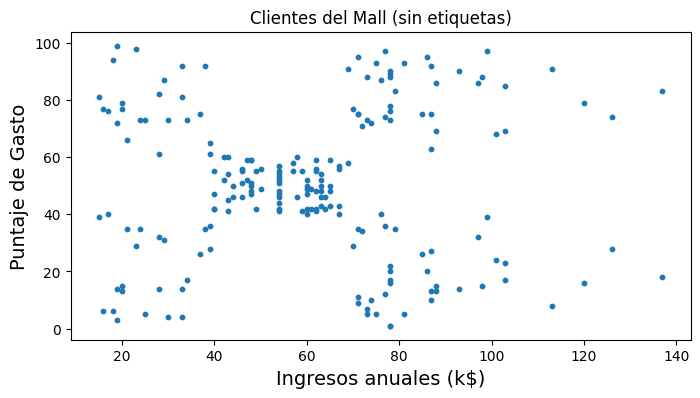

In [4]:
def plot_clusters(data, y=None):
    plt.scatter(data[:, 0], data[:, 1], c=y, s=10)
    plt.xlabel('Ingresos anuales (k$)', fontsize=14)
    plt.ylabel('Puntaje de Gasto', fontsize=14, rotation=90)

plt.figure(figsize=(8, 4))
plot_clusters(X_data)
plt.title('Clientes del Mall (sin etiquetas)')
plt.show()

In [5]:
# AQUI CAMBIA: k desconocido
K = range(2, 11)
wcss = []
sil_scores = []

for k_try in K:
    km = KMeans(n_clusters=k_try, random_state=42, n_init=10)
    yk = km.fit_predict(X_data)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_data, yk))

In [6]:
def detectar_codo_por_distancia(ks, inercias):
    p1 = np.array([ks[0], inercias[0]], dtype=float)
    p2 = np.array([ks[-1], inercias[-1]], dtype=float)
    distancias = []
    for k_val, iner in zip(ks, inercias):
        p = np.array([k_val, iner], dtype=float)
        num = np.abs(np.cross(p2 - p1, p1 - p))
        den = np.linalg.norm(p2 - p1)
        distancias.append(num / den)
    return ks[int(np.argmax(distancias))]

k_codo = detectar_codo_por_distancia(list(K), wcss)
k_sil = list(K)[int(np.argmax(sil_scores))]
k_final = int(round((k_codo + k_sil) / 2))

print('Seleccion automatica de k')
print('k por codo:', k_codo)
print('k por silhouette:', k_sil)
print('k final recomendado:', k_final)

Seleccion automatica de k
k por codo: 5
k por silhouette: 5
k final recomendado: 5


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_5312\1742241274.py:7: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  num = np.abs(np.cross(p2 - p1, p1 - p))


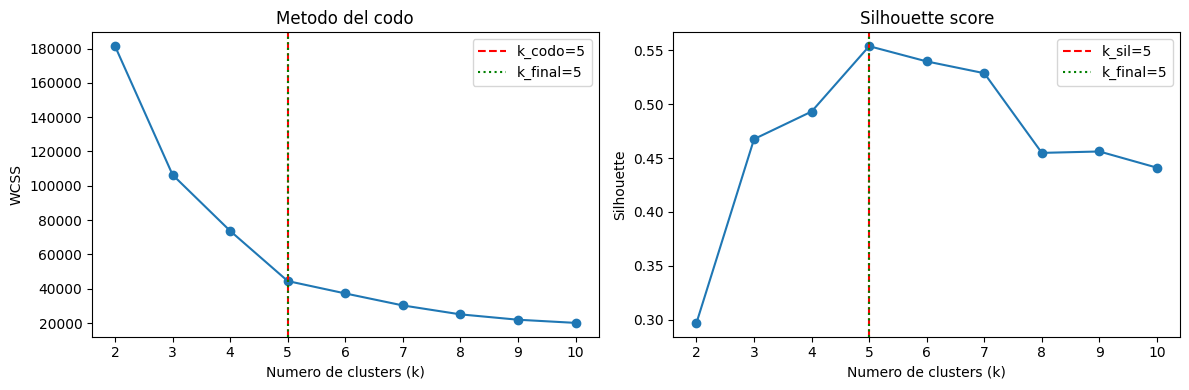

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(list(K), wcss, marker='o')
plt.axvline(k_codo, color='red', linestyle='--', label=f'k_codo={k_codo}')
plt.axvline(k_final, color='green', linestyle=':', label=f'k_final={k_final}')
plt.title('Metodo del codo')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('WCSS')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(list(K), sil_scores, marker='o')
plt.axvline(k_sil, color='red', linestyle='--', label=f'k_sil={k_sil}')
plt.axvline(k_final, color='green', linestyle=':', label=f'k_final={k_final}')
plt.title('Silhouette score')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Silhouette')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_data)

print('Etiquetas de cluster (primeros 20):')
print(y_pred[:20])

print('\nCentroides:')
print(kmeans.cluster_centers_)

Etiquetas de cluster (primeros 20):
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2]

Centroides:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [9]:
# Prediccion de nuevos puntos
X_new = np.array([[50, 50], [100, 80], [20, 20], [80, 10]])
print('Cluster asignado a nuevos puntos:')
print(kmeans.predict(X_new))

Cluster asignado a nuevos puntos:
[0 1 4 3]


In [10]:
def plot_data(data):
    plt.plot(data[:, 0], data[:, 1], 'k.', markersize=4)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='o',
        s=10,
        linewidths=8,
        color=circle_color,
        zorder=10,
        alpha=0.9,
    )
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='x',
        s=2,
        linewidths=10,
        color=cross_color,
        zorder=11,
        alpha=1,
    )

def plot_decision_boundaries(
    clusterer,
    data,
    resolution=1000,
    show_centroids=True,
    show_xlabels=True,
    show_ylabels=True,
):
    mins = data.min(axis=0) - 0.1
    maxs = data.max(axis=0) + 0.1
    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution),
    )
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap='Pastel2')
    plt.contour(
        Z,
        extent=(mins[0], maxs[0], mins[1], maxs[1]),
        linewidths=1,
        colors='k',
    )
    plot_data(data)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel('Annual Income (k$)', fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel('Spending Score', fontsize=14, rotation=90)
    else:
        plt.tick_params(labelleft=False)

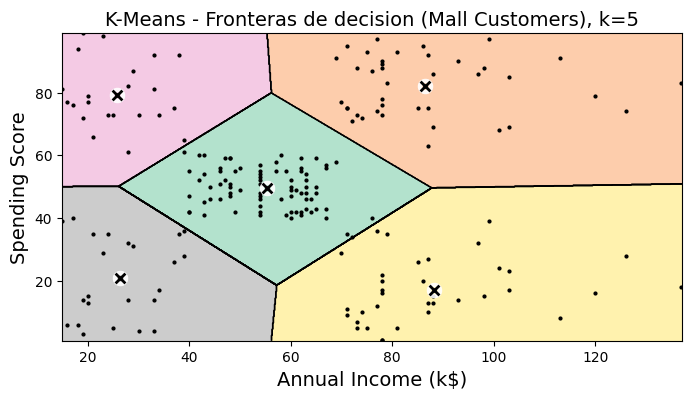

In [11]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X_data)
plt.title(f'K-Means - Fronteras de decision (Mall Customers), k={k_final}', fontsize=14)
plt.show()